# Customer Retention Cohort Analysis
## Project Overview
This project analyzes customer retention across various cohorts, focusing on user behavior over time. By leveraging cohort analysis, we track the percentage of users retained at different points in time (e.g., weeks or months) after they first joined. This project uses real-world customer data to identify trends in user retention, providing valuable insights into how long customers stay active and when they tend to drop off. The analysis includes both static and interactive visualizations, allowing for detailed exploration of retention trends.

The markdowns included explain each step of the analysis, making it easy for others to follow along and adapt the techniques for their own datasets. This project can be used as a guide to perform cohort retention analysis on any dataset where user behavior over time is of interest.

### Techniques Used:
* Data Cleaning: Preprocessing and reshaping the data for cohort analysis, ensuring accuracy and completeness.
* Cohort Analysis: Grouping users by cohort (based on when they first interacted with the product or service) and tracking their retention rates over time.
* Retention Calculations: Calculating the percentage of users retained in each cohort over defined time periods.
* Heatmap: Shows retention rates across cohorts, where each row represents a different cohort (grouped by the month of customer acquisition), and the X-axis represents the number of months since acquisition.
* Static Line Plot: Visualizing retention rates for each cohort, displaying trends in customer behavior over time.
* Interactive Line Plot: Creating an interactive visualization that allows users to hover over data points and see retention percentages for specific cohorts and periods.


## Step 1: Loading and Inspecting the Dataset
In this initial step, we load the dataset containing customer records for analysis. This step focuses on understanding the structure and composition of the data to ensure it is suitable for cohort analysis.

In [144]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff

# Load the dataset and inspect its structure
df = pd.read_csv('US_Ecommerce_records_2020.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null 

### Behind the Code:
#### 1. Loading the Dataset:
We begin by reading the CSV file that contains e-commerce records. The info() method is used to check the structure of the dataset, ensuring we understand the types of variables we're working with.

#### 2. Data Cleaning:
Customer ID: Since customer IDs are essential for tracking unique users over time, we extract the numeric portion of the Customer ID field and convert it into an integer for easier manipulation.
Order Date: Converting Order Date to a datetime format ensures that we can perform time-based operations later, which will be crucial when creating retention cohorts.

#### 3. Verification:
Finally, we print the dataset and check the updated data types to confirm that the transformations were successful. This step ensures that both the customer IDs and order dates are in formats suitable for retention analysis.

* Order Date: Converted to datetime64[ns] for proper date-based operations.
* Customer ID Int: A new column created with the type int32, ensuring it’s easier to track customers across sessions.

In [146]:
# Convert Customer ID to integer and Order Date to datetime format
df['Customer ID Int'] = df['Customer ID'].str.extract(r'(\d+)', expand=False).astype(int)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

# View the updated dataframe and data types
print(df)
print(df.dtypes)

     Order Date  Row ID        Order ID       Ship Mode Customer ID  \
0    2020-01-01     849  CA-2017-107503  Standard Class    GA-14725   
1    2020-01-01    4010  CA-2017-144463  Standard Class    SC-20725   
2    2020-01-01    6683  CA-2017-154466     First Class    DP-13390   
3    2020-01-01    8070  CA-2017-151750  Standard Class    JM-15250   
4    2020-01-01    8071  CA-2017-151750  Standard Class    JM-15250   
...         ...     ...             ...             ...         ...   
3307 2020-12-30     908  CA-2017-143259  Standard Class    PO-18865   
3308 2020-12-30     909  CA-2017-143259  Standard Class    PO-18865   
3309 2020-12-30    1297  CA-2017-115427  Standard Class    EB-13975   
3310 2020-12-30    1298  CA-2017-115427  Standard Class    EB-13975   
3311 2020-12-30    5092  CA-2017-156720  Standard Class    JM-15580   

          Segment        Country           City       State  Postal Code  \
0        Consumer  United States         Lorain        Ohio        4405

## Step 2: Cohort Analysis — Assigning Acquisition Month Cohort
To analyze user retention, we need to group customers by the month they first made a purchase. This will allow us to track how long customers from each cohort continue using the product over time. The first step in cohort analysis is assigning an acquisition month to each customer.

In [148]:
# Import the datetime module
import datetime as dt

# Function to get the first day of the month
def get_month(x):
    return dt.datetime(x.year, x.month, 1)

# Apply the function to create a new 'Order Month' column
df['Order Month'] = df['Order Date'].apply(get_month)

# Group by 'Customer ID' and find the earliest purchase month for each customer
grouping = df.groupby('Customer ID')['Order Month']
df['CohortMonth'] = grouping.transform('min')

# Display the updated dataframe
df.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Customer ID Int,Order Month,CohortMonth
0,2020-01-01,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,...,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568,14725,2020-01-01,2020-01-01
1,2020-01-01,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,...,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606,20725,2020-01-01,2020-01-01
2,2020-01-01,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,...,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280,13390,2020-01-01,2020-01-01
3,2020-01-01,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,...,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580,15250,2020-01-01,2020-01-01
4,2020-01-01,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,...,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815,15250,2020-01-01,2020-01-01


### Behind the Code:
#### 1. Assigning Order Month:
The get_month() function is designed to capture the year and month of each purchase, ignoring the day to simplify the analysis. This is applied to the Order Date column, creating a new column called Order Month, which represents the month each order was placed.

#### 2. Creating Cohorts:
We group the data by Customer ID to identify the cohort month—the earliest month in which each customer made their first purchase. This new column, CohortMonth, will allow us to track the behavior of customers acquired in the same month as a cohort.

#### 3. Purpose:
Assigning cohort months is the foundation of retention analysis, as it allows us to measure how long users from each acquisition group continue to engage with the platform over time.

## Step 3: Extracting Integer Values and Calculating Cohort Index
In order to calculate the time offset between when a user was first acquired and their subsequent activities, we need to extract specific date components (year, month, and day) from the Order Month and CohortMonth columns. This will allow us to create a new feature called the Cohort Index, which tracks the number of months between the user's acquisition and their activities over time.

In [151]:
# Helper function to extract integer values from a datetime object
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    day = df[column].dt.day
    return year, month, day

# Extract year and month from both 'Order Month' and 'CohortMonth'
order_year, order_month, _ = get_date_int(df, 'Order Month')
cohort_year, cohort_month, _ = get_date_int(df, 'CohortMonth')

# Calculate the difference in years and months between the order date and cohort date
years_diff = order_year - cohort_year
months_diff = order_month - cohort_month

# Create the 'CohortIndex' column to track the time offset in months
df['CohortIndex'] = years_diff * 12 + months_diff + 1

# Display the updated dataframe
df.head()


,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Customer ID Int,Order Month,CohortMonth,CohortIndex
0,2020-01-01,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,...,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568,14725,2020-01-01,2020-01-01,1
1,2020-01-01,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,...,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606,20725,2020-01-01,2020-01-01,1
2,2020-01-01,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,...,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280,13390,2020-01-01,2020-01-01,1
3,2020-01-01,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,...,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580,15250,2020-01-01,2020-01-01,1
4,2020-01-01,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,...,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815,15250,2020-01-01,2020-01-01,1


### Behind the Code:
#### 1. Helper Function — get_date_int():
This function extracts the year, month, and day from a datetime object in the dataset. By returning these integer values, it allows us to manipulate date-related columns and calculate time differences.
#### 2. Calculating the Time Offset:
* Order vs. Cohort Dates: We extract the year and month for both Order Month (when the purchase was made) and CohortMonth (when the customer was first acquired).
* Time Difference: By subtracting the cohort year and month from the order year and month, we calculate how many months have passed since the customer was first acquired.
#### 3. Creating the Cohort Index:
The CohortIndex column represents the time offset (in months) for each order relative to when the customer was acquired. This is crucial for tracking how long customers remain engaged with the product.

## Step 4: Grouping and Calculating Retention Rates
To accurately measure retention, it’s necessary to group and process the data in a way that allows us to calculate retention rates for each cohort over time. This will give us the insight needed to understand user engagement across different acquisition periods.

In [154]:
grouping = df.groupby(['CohortMonth', 'CohortIndex'])
cohort_data = grouping['Customer ID'].apply(pd.Series.nunique)
cohort_data = cohort_data.reset_index()

cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')
print(cohort_counts)

CohortIndex     1     2     3     4     5     6     7     8     9     10  \
CohortMonth                                                                
2020-01-01    96.0  10.0  18.0  23.0   7.0  13.0  11.0  19.0  22.0  13.0   
2020-02-01    90.0  13.0  13.0   8.0  11.0  15.0  15.0  18.0  15.0  23.0   
2020-03-01   111.0  24.0  13.0  17.0  18.0  10.0  22.0  17.0  26.0  20.0   
2020-04-01    65.0  14.0  14.0  11.0  12.0  19.0  11.0  18.0  14.0   NaN   
2020-05-01    63.0   9.0   7.0  10.0  10.0   9.0  19.0  13.0   NaN   NaN   
2020-06-01    56.0   6.0  12.0  13.0  10.0  12.0  11.0   NaN   NaN   NaN   
2020-07-01    42.0   9.0   9.0   4.0   7.0   5.0   NaN   NaN   NaN   NaN   
2020-08-01    29.0   5.0   6.0   5.0   7.0   NaN   NaN   NaN   NaN   NaN   
2020-09-01    48.0   9.0  15.0  12.0   NaN   NaN   NaN   NaN   NaN   NaN   
2020-10-01    41.0  10.0   4.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2020-11-01    29.0   5.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2020-12-01  

### Behind the Code:
#### 1. Grouping by CohortMonth and CohortIndex:
The goal here is to group customers by their CohortMonth (the month they were first acquired) and CohortIndex (how many months have passed since they were first acquired). This creates the foundation for calculating how many unique customers remain active in each cohort over time.
* CohortMonth: Represents the acquisition month for each customer. This helps us track retention by the period when users first started interacting with the product.
* CohortIndex: Tracks the elapsed time for each customer after their initial acquisition. This index allows us to see how long customers remain active over several months.
#### 2. Creating a Pivot Table:
After grouping the data, we pivot it into a table format where each row represents a cohort (based on the acquisition month), and each column represents the number of months (CohortIndex) since that cohort’s acquisition. The pivot table allows us to see the number of unique customers still active in each cohort over time. Without this step, we wouldn’t have a clear view of retention behavior, making it difficult to generate accurate insights.

## Step 5: Calculating Retention Rates
Once we have the pivot table showing the number of unique customers over time, we calculate the retention rate. The retention rate tells us what percentage of customers from a given cohort continue to engage with the product over time.
### Why this is necessary:
Retention rates provide insight into how well users are being retained over time. It’s not enough to know the number of users remaining in each cohort; we need to express this as a percentage to make meaningful comparisons between cohorts.

In [157]:
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention.round(3) * 100

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2020-01-01,100.0,10.4,18.8,24.0,7.3,13.5,11.5,19.8,22.9,13.5,17.7,19.8
2020-02-01,100.0,14.4,14.4,8.9,12.2,16.7,16.7,20.0,16.7,25.6,16.7,NaN
2020-03-01,100.0,21.6,11.7,15.3,16.2,9.0,19.8,15.3,23.4,18.0,NaN,NaN
2020-04-01,100.0,21.5,21.5,16.9,18.5,29.2,16.9,27.7,21.5,NaN,NaN,NaN
2020-05-01,100.0,14.3,11.1,15.9,15.9,14.3,30.2,20.6,NaN,NaN,NaN,NaN
2020-06-01,100.0,10.7,21.4,23.2,17.9,21.4,19.6,NaN,NaN,NaN,NaN,NaN
2020-07-01,100.0,21.4,21.4,9.5,16.7,11.9,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-01,100.0,17.2,20.7,17.2,24.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,100.0,18.8,31.2,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Behind the Code:
#### 1. Calculate Cohort Size:
We first extract the size of each cohort from the pivot table. This gives us the baseline number of users that started in each cohort (i.e., the total number of users acquired in each month).
#### 2. Calculate Retention Rates:
Next, we divide the number of active users in each cohort over time by the cohort size. This gives us the retention rate, expressed as a percentage of the original cohort that continues to be active.

## Step 6: Visualizing Cohort Retention
### Retention Heatmap
In this step, we visualize the user retention rates across different cohorts over time using a heatmap.

The heatmap shows retention rates across cohorts, where each row represents a different cohort (grouped by the month of customer acquisition). The X-axis represents the number of months since acquisition, while the color scale represents the retention percentage.

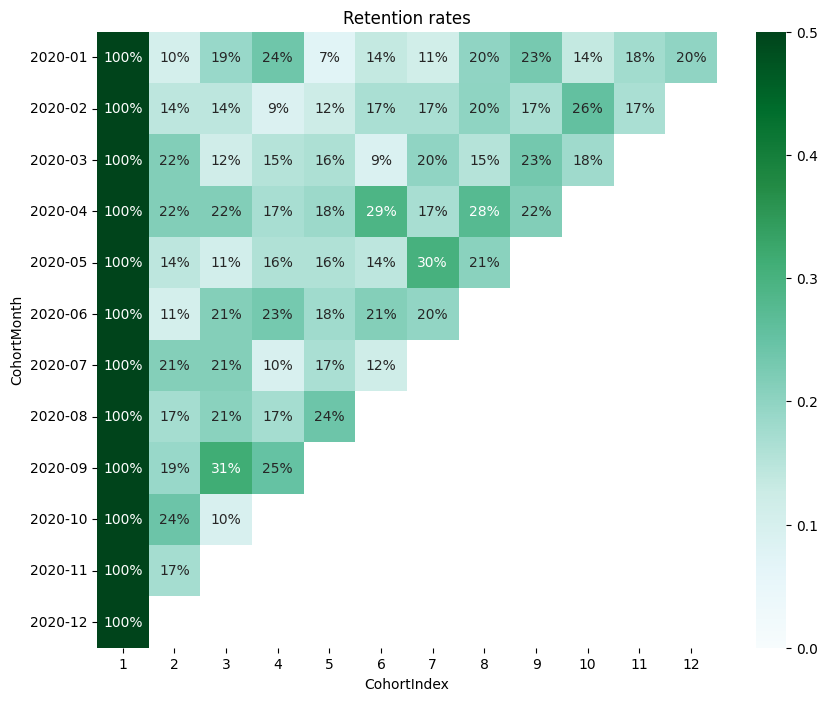

In [160]:
# Visualizing cohort analysis with a standard heatmap
plt.figure(figsize=(10,8))
plt.title('Retention rates')
sns.heatmap(data=retention,
            annot=True,
            fmt='.0%',
            vmin=0.0,
            vmax=0.5,
            cmap='BuGn')
plt.gca().set_yticklabels(retention.index.strftime('%Y-%m'))
plt.show()

### Static Line Plot
In this step, we visualize the user retention rates across different cohorts over time using line plots. The line plot provides a clear view of how user retention decreases (or remains steady) over time for each cohort.

The static line plot displays the retention rates for different cohorts over time. Each line represents a different cohort, where the X-axis shows the number of periods (e.g., months, weeks) that have passed since the cohort was created, and the Y-axis shows the retention percentage for that cohort at each period.

* **X-axis:** Represents the number of periods elapsed (Cohort Index), showing how far the cohort is from its start date.
* **Y-axis:** Represents the percentage of users retained in each cohort, with 100% being the starting point at period 1.
* **Lines:** Each line represents a cohort, allowing us to track user drop-off over time. A steeper drop suggests a rapid decline in user retention, while flatter lines suggest better retention.

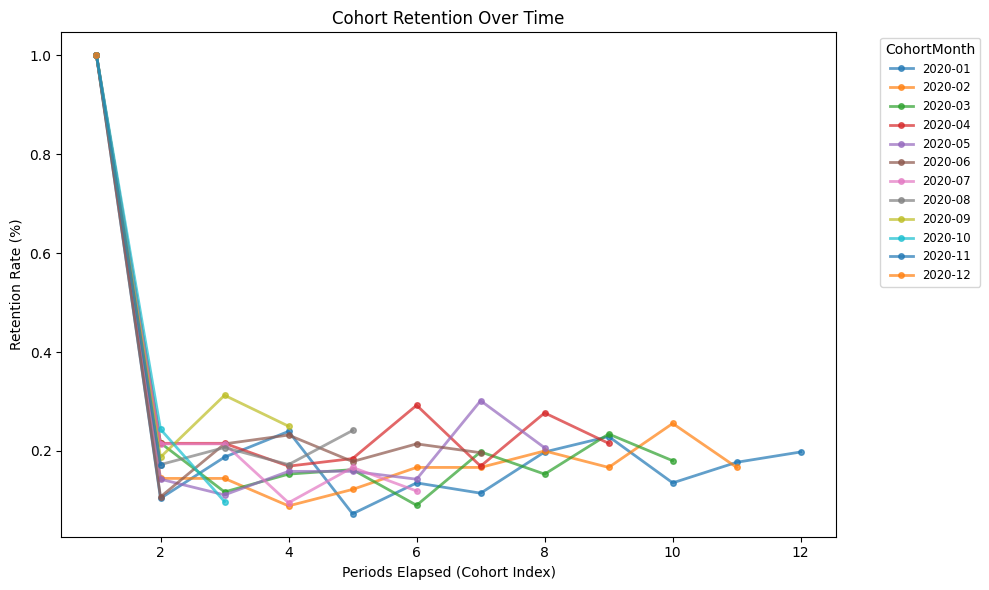

In [162]:
import matplotlib.pyplot as plt

# Plotting the retention lines for each cohort
plt.figure(figsize=(10, 6))

# Plot a line for each cohort
for cohort in retention.index:
    plt.plot(
        retention.columns, 
        retention.loc[cohort], 
        marker='o', 
        label=cohort.strftime('%Y-%m'),
        alpha=0.7,  # Transparency to reduce clutter
        linewidth=2,  # Slightly thicker lines
        markersize=4  # Smaller markers for clarity
    )

# Add plot labels and title
plt.title('Cohort Retention Over Time')
plt.xlabel('Periods Elapsed (Cohort Index)')
plt.ylabel('Retention Rate (%)')

# Add a legend with a smaller font size and moving it outside the plot area
plt.legend(title='CohortMonth', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# Show the plot with improved layout
plt.tight_layout()
plt.show()

### **Preparing Data for Visualizing Retention**
In this step, we prepare the dataset for creating interactive retention line plots. The goal is to transform the retention DataFrame from a wide format into a long format, where each row represents a cohort-period combination, making it suitable for visualization.

In [164]:
# Reset the index to convert cohort months to a 'cohort_date' column
df_retention = retention.reset_index()

# Rename the first column as 'cohort_date'
df_retention.rename(columns={df_retention.columns[0]: 'cohort_date'}, inplace=True)

# Now we melt the DataFrame to get a long-form structure
df_retention = df_retention.melt(id_vars='cohort_date', var_name='period_index', value_name='pct_users')

# Drop NaN values (which may occur due to incomplete data)
df_retention.dropna(inplace=True)

# Ensure period_index is numeric for plotting
df_retention['period_index'] = df_retention['period_index'].astype(int)

# Preview the processed DataFrame
print(df_retention.head())

  cohort_date  period_index  pct_users
0  2020-01-01             1        1.0
1  2020-02-01             1        1.0
2  2020-03-01             1        1.0
3  2020-04-01             1        1.0
4  2020-05-01             1        1.0


### **Verifying Data Accuracy After Reshaping**
After transforming the retention data into a long format, it's essential to verify that the reshaping process has not altered the data. This step involves checking the shape of the DataFrame and comparing specific values to ensure consistency.

#### 1. Checking DataFrame Shape:

We first compare the shape of the original and reshaped DataFrames to confirm that no data was inadvertently added or removed.

In [166]:
# Before reshaping (retention DataFrame)
print("Original Retention DataFrame Shape:", retention.shape)

# After reshaping (df_retention DataFrame)
print("Processed Retention DataFrame Shape:", df_retention.shape)

Original Retention DataFrame Shape: (12, 12)
Processed Retention DataFrame Shape: (78, 3)


#### 2. Comparing Data Values:

Next, we ensure the data remained consistent by comparing retention values for a specific cohort and period before and after reshaping.

The values are nearly identical, confirming the transformation preserved data accuracy. The small difference is due to floating-point precision.

In [168]:
# Compare a specific cohort and period from the original retention DataFrame
cohort_to_check = '2020-01'  # Example cohort
period_to_check = 2  # Example period (CohortIndex)

# Value in the original retention DataFrame
original_value = retention.loc[cohort_to_check, period_to_check]
print(f"Original Value for {cohort_to_check} in Period {period_to_check}: {original_value}")

# Value in the processed DataFrame
processed_value = df_retention[(df_retention['cohort_date'] == cohort_to_check) &
                               (df_retention['period_index'] == period_to_check)]['pct_users'].values[0]
print(f"Processed Value for {cohort_to_check} in Period {period_to_check}: {processed_value}")

Original Value for 2020-01 in Period 2: CohortMonth
2020-01-01    0.104167
Name: 2, dtype: float64
Processed Value for 2020-01 in Period 2: 0.10416666666666667


### Interactive Line Plot:
The interactive line plot provides the same retention data but with additional features. You can hover over individual points on the plot to see detailed data for each cohort and period. This interactivity makes it easier to explore specific values without cluttering the plot.

* **Hover Data:** When you hover over a point, you can see the exact cohort, period, and retention rate for that specific point.
* **X-axis:** Represents the number of periods elapsed (Cohort Index).
* **Y-axis:** Represents the retention percentage for each cohort.
* **Lines:** Each line represents a cohort. Hovering over any point on the line provides detailed retention data for that cohort and period.

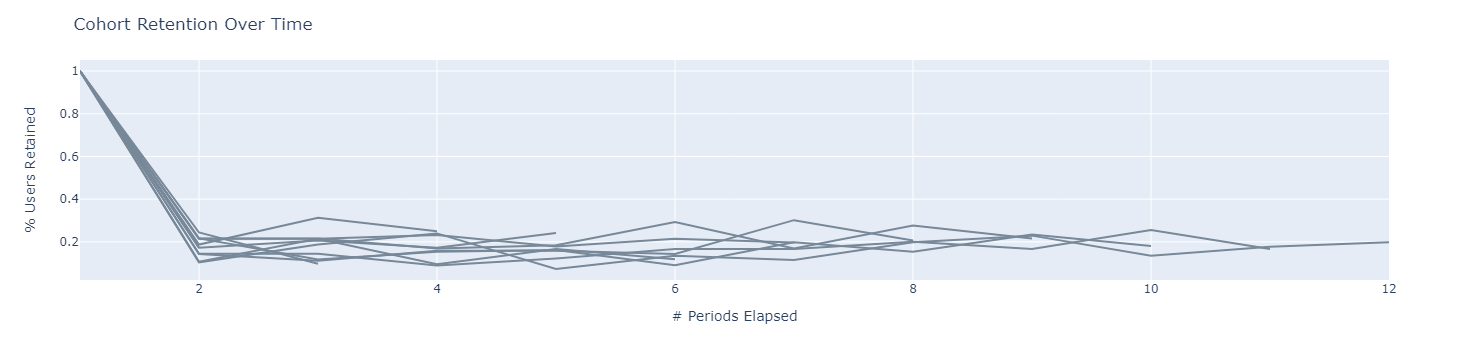

In [170]:
import plotly.express as px

# Function to plot cohort retention lines using Plotly
def plot_cohort_lines(df, nb_periods=15):
    df['cohort_date'] = df['cohort_date'].astype(str)  # Ensure cohort dates are strings for display
    
    # Create the line plot with Plotly
    fig = px.line(
        df.query('period_index > 0 & period_index <= @nb_periods'),  # Filter periods
        x='period_index',  # X-axis: periods elapsed
        y='pct_users',  # Y-axis: percentage of users retained
        line_group='cohort_date',  # Each cohort gets its own line
        hover_data=['cohort_date', 'period_index', 'pct_users'],  # Data to show on hover
        color_discrete_sequence=["lightslategray"]  # Customize color if needed
    )

    # Update layout for better readability
    fig.update_layout(
        xaxis={"title": "# Periods Elapsed"},
        yaxis={"title": "% Users Retained"},
        title="Cohort Retention Over Time"
    )
    
    return fig

# Call the function and display the interactive plot
fig_lines = plot_cohort_lines(df_retention)  # Assuming df_retention is your processed DataFrame
fig_lines.show(config={"displayModeBar": False})  # Disable the display mode bar for a cleaner view

### Key Insights:
#### 1. Initial Retention Rates:
Each cohort begins with 100% retention, as expected, since the first column (CohortIndex = 1) represents the month when all customers were acquired.
#### 2. Retention Decline:
A significant drop in retention occurs between the first and second months across most cohorts. For example, the January 2020 cohort shows a decline from 100% to 24% in the second month, indicating that a large portion of customers did not return after the initial purchase.
Retention continues to decrease over time, with most cohorts showing single-digit retention rates after 6-7 months.
#### 3. Variations Between Cohorts:
Some cohorts, such as those from May 2020 and June 2020, exhibit stronger retention rates in later months (e.g., 30% in month 7 for May 2020).
Cohorts from the second half of the year, such as November and December 2020, appear to have shorter data, indicating they are more recent acquisitions.
#### 4. Long-Term Retention:
By the 12th month, few cohorts maintain double-digit retention rates. However, the January 2020 cohort retains 20% of its original customers, suggesting long-term engagement for a portion of the cohort.

## Conclusion
Thank you for reviewing my Cohort Retention Analysis project! Through this analysis, we've highlighted how retention rates evolve for different cohorts and visualized the drop-off in user engagement over time. Understanding these patterns is essential for improving customer retention strategies and creating more effective customer outreach campaigns. I hope you found the techniques demonstrated here, both static and interactive visualizations, useful for your own projects.

